# SOB4ES - Modelo XGBoost
### CRISP-ML(Q) - Fase 3 y 4: Desarrollo y evaluacion de los modelos

Este notebook recorre el ciclo de vida completo del modelo de inteligencia artificial.

**Datasets utilizados:**
- `train.csv` - Entrenamiento del modelo (70 % del total, estratificado por pais)
- `test.csv`  - Busqueda de hiperparametros y validacion cruzada (15 %)
- `eval.csv`  - Evaluacion final e imparcial del rendimiento (15 %)

**Estructura del notebook:**
1. **Configuracion:** Importaciones y parametros globales.
2. **Carga de datos:** Se cargan los tres splits pre-generados.
3. **Tuning:** Busqueda aleatoria de la mejor combinacion de hiperparametros.
4. **Validacion cruzada:** Evaluacion de robustez mediante repeticion de pliegues.
5. **Explicabilidad (SHAP):** Analisis de importancia de variables.
6. **Produccion:** Entrenamiento del ensamble final y exportacion de modelos.
7. **Evaluacion final:** Medicion del rendimiento real sobre `eval.csv`.

---
## 1.- Configuracion del entorno
Importaciones y configuracion de rutas y variables globales.

In [7]:
import os
import time
import warnings
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt

import shap
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_validate, KFold

import seaborn as sns

# ignoramos los warnings
warnings.filterwarnings('ignore')
#os.environ["PYTHONWARNINGS"] = "ignore"

DATA_DIR   = 'input/'
MODELS_DIR = 'output/models/XGBoost'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)

TARGETS = [
    # Shannon diversity index
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]


FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    'cu_z',
    'k_z',
    'mo_z',
    'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]


print('Librerias y variables cargadas.')

Librerias y variables cargadas.


## 2.- Carga de datos

Se cargan los tres datasets pre-generados a partir de la division 70/15/15 estratificada por pais.

| Archivo    | Uso                                      | Filas aprox. |
|------------|------------------------------------------|--------------|
| `train.csv`| Ajuste del modelo                        | 299          |
| `test.csv` | Tuning de hiperparametros / Val. cruzada | 64           |
| `eval.csv` | Evaluacion final imparcial               | 65           |

El dataset `eval.csv` no se utiliza hasta la seccion 7 para garantizar una estimacion imparcial del rendimiento.

In [8]:
def cargar_csv(ruta, nombre):
    """Carga un CSV (sep=',' o ';') y valida las columnas necesarias."""
    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No se encontro el archivo: {ruta}")
    try:
        df = pd.read_csv(ruta, sep=',')
        if len(df.columns) < 5:
            df = pd.read_csv(ruta, sep=';')
    except Exception:
        df = pd.read_csv(ruta, sep=';')
    print(f"  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas")
    return df

print("Cargando datasets...")
df_train = cargar_csv(os.path.join(DATA_DIR, 'train.csv'), 'train.csv')
df_test  = cargar_csv(os.path.join(DATA_DIR, 'test.csv'),  'test.csv')
df_eval  = cargar_csv(os.path.join(DATA_DIR, 'eval.csv'),  'eval.csv')

X_train = df_train[FEATURES_AUTORIZADAS]
y_train = df_train[TARGETS]

X_test  = df_test[FEATURES_AUTORIZADAS]
y_test  = df_test[TARGETS]

X_eval  = df_eval[FEATURES_AUTORIZADAS]   # no se usa hasta la seccion 7
y_eval  = df_eval[TARGETS]               # no se usa hasta la seccion 7

print(f"\nDatasets cargados.")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  X_eval: {X_eval.shape}")

Cargando datasets...
  train.csv: 299 filas x 71 columnas
  test.csv: 64 filas x 71 columnas
  eval.csv: 65 filas x 71 columnas

Datasets cargados.
X_train: (299, 34)  |  X_test: (64, 34)  |  X_eval: (65, 34)


## 3.- Busqueda de hiperparametros (Tuning)

Se realiza una busqueda aleatoria (`RandomizedSearchCV`) sobre el espacio de hiperparametros del modelo XGBoost. La busqueda se ejecuta exclusivamente sobre `X_train` para evitar cualquier fuga de informacion hacia los splits de validacion y evaluacion.

Como variable objetivo de referencia se usa `earthworm_shannon_z` (lombrices de tierra).


Para combatir el sobreajuste observado (Train R2 ~0.99, Val R2 ~0.47) se aplican tres medidas:
- Grid mas conservador: `max_depth` maximo 4, `n_estimators` maximo 300.
- Regularizacion L1/L2: se añaden `reg_alpha` y `reg_lambda` al grid.
- Early stopping: el entrenamiento para cuando el rendimiento en `X_test` deja de mejorar durante 20 iteraciones consecutivas.


In [9]:
print("Iniciando busqueda de hiperparametros (Tuning)...")
print("Este proceso puede tardar varios minutos.\n")

param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [2, 3, 4],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'gamma':            [0.1, 0.3, 0.5, 1.0],
    'min_child_weight': [3, 5, 7],
    'reg_alpha':        [0.0, 0.1, 0.5, 1.0],
    'reg_lambda':       [1.0, 2.0, 5.0]
}

y_prueba = y_train['earthworm_shannon_z'].values

buscador_exhaustivo = RandomizedSearchCV(
    estimator=XGBRegressor(tree_method='hist', random_state=42),
    param_distributions=param_grid,
    n_iter=50,
    scoring='r2',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

import time
start_tune = time.time()
buscador_exhaustivo.fit(X_train, y_prueba)

print(f"\nBusqueda completada en {(time.time() - start_tune)/60:.1f} minutos.")
print(f"Mejor R2 obtenido: {buscador_exhaustivo.best_score_:.4f}")
print(f"Hiperparametros optimos: {buscador_exhaustivo.best_params_}")

XGB_OPTIMAL_PARAMS = buscador_exhaustivo.best_params_
XGB_OPTIMAL_PARAMS['tree_method'] = 'hist'
XGB_OPTIMAL_PARAMS['random_state'] = 42

Iniciando busqueda de hiperparametros (Tuning)...
Este proceso puede tardar varios minutos.

Fitting 5 folds for each of 50 candidates, totalling 250 fits



Busqueda completada en 0.3 minutos.
Mejor R2 obtenido: 0.5052
Hiperparametros optimos: {'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alpha': 0.0, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 1.0, 'colsample_bytree': 0.6}


## 4.- Validacion cruzada

Se evalua la robustez del modelo mediante validacion cruzada repetida (5 pliegues x 3 repeticiones = 15 evaluaciones) aplicada sobre `X_train`. Esto permite detectar sobreajuste comparando el rendimiento en entrenamiento y en los pliegues de validacion.

In [10]:
from sklearn.model_selection import RepeatedKFold

print('Validacion cruzada repetida (15 evaluaciones sobre X_train)...\n')

modelo_evaluacion   = XGBRegressor(**XGB_OPTIMAL_PARAMS)
cortador_implacable = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
metricas            = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']

# La validacion cruzada usa earthworm_shannon_z como target de referencia.
# Los hiperparametros optimos se aplican despues a todos los targets en produccion.
resultados_examen = cross_validate(
    estimator=modelo_evaluacion,
    X=X_train,
    y=y_train['earthworm_shannon_z'].values,
    cv=cortador_implacable,
    scoring=metricas,
    return_train_score=True
)

r2_entrenamiento = np.mean(resultados_examen['train_r2'])
r2_examen_real   = np.mean(resultados_examen['test_r2'])
r2_desviacion    = np.std(resultados_examen['test_r2'])
rmse_real        = np.mean(-resultados_examen['test_neg_root_mean_squared_error'])
mae_real         = np.mean(-resultados_examen['test_neg_mean_absolute_error'])

print('Resultados (promedio de 15 evaluaciones):')
print(f'  Train R2          : {r2_entrenamiento:.4f}')
print(f'  Validacion R2 (CV): {r2_examen_real:.4f} +/- {r2_desviacion:.4f}')
print(f'  RMSE              : {rmse_real:.4f} puntos de Shannon H\'')
print(f'  MAE               : {mae_real:.4f} puntos de Shannon H\'')

diferencia = r2_entrenamiento - r2_examen_real
if diferencia > 0.15:
    print(f'\nAviso: diferencia train/validacion = {diferencia:.4f}. Posible sobreajuste.')
else:
    print(f'\nDiferencia train/validacion = {diferencia:.4f}. El modelo generaliza correctamente.')

Validacion cruzada repetida (15 evaluaciones sobre X_train)...

Resultados (promedio de 15 evaluaciones):
  Train R2          : 0.8411
  Validacion R2 (CV): 0.4837 +/- 0.1014
  RMSE              : 0.6932 puntos de Shannon H'
  MAE               : 0.5115 puntos de Shannon H'

Aviso: diferencia train/validacion = 0.3574. Posible sobreajuste.


## 5.- Explicabilidad del modelo (SHAP)

Se utiliza SHAP (SHapley Additive exPlanations) para identificar que variables influyen mas en las predicciones del modelo y en que direccion lo hacen.

El grafico de puntos muestra las 10 variables mas importantes:
- Las variables se ordenan de mayor a menor importancia global (de arriba a abajo).
- El color indica el valor de la variable (rojo = valor alto, azul = valor bajo).
- La posicion horizontal indica el efecto sobre la prediccion (derecha = aumenta el indice, izquierda = lo reduce).

Calculando valores SHAP sobre X_train...
Top 10 variables por importancia SHAP (earthworm_shannon_z):


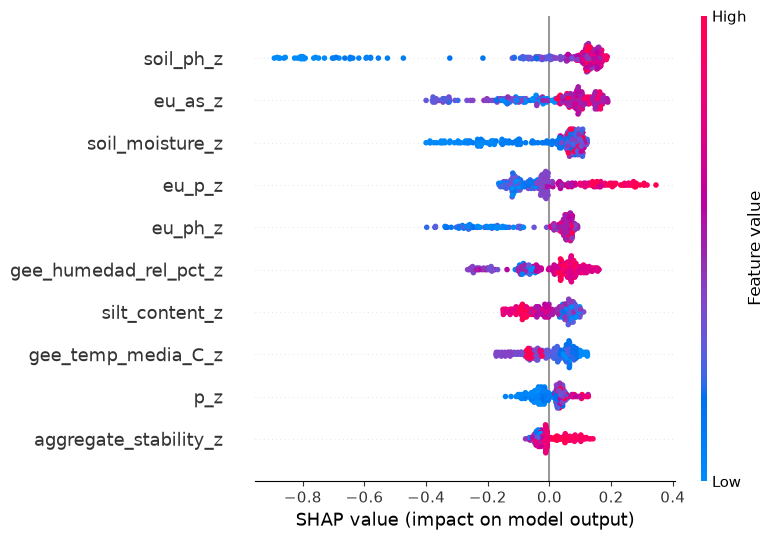

Top 10 variables por importancia SHAP (earthworm_richness_z):


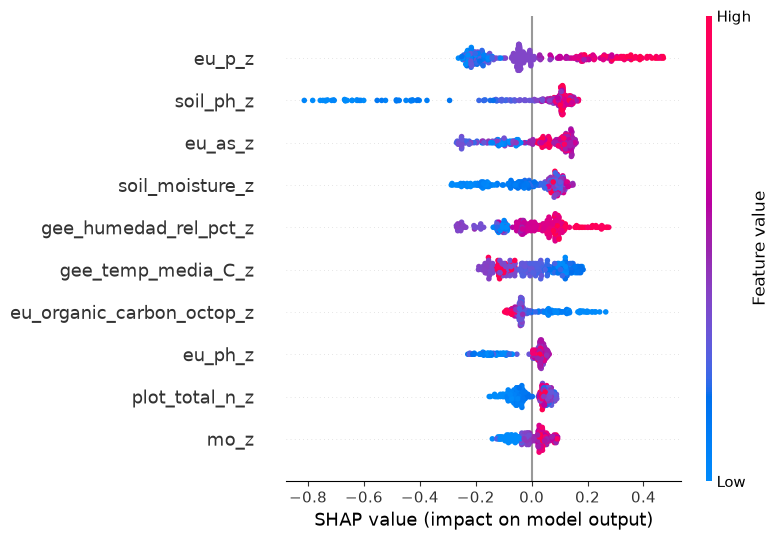

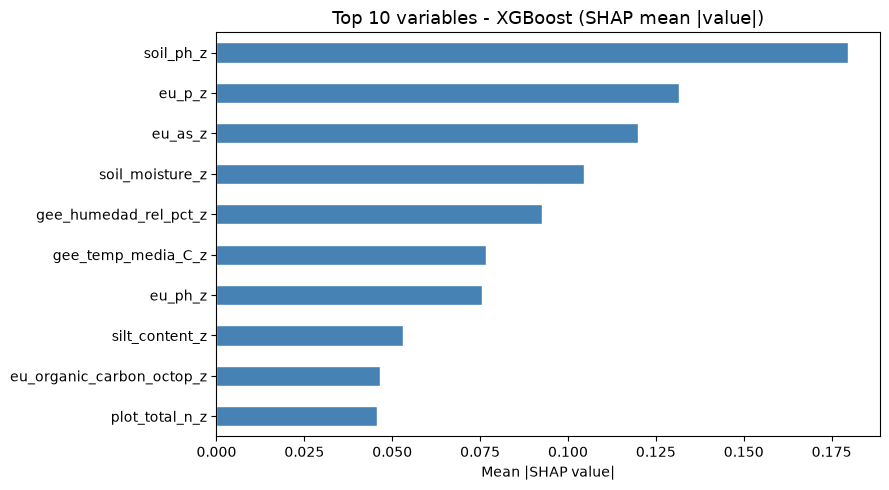

In [11]:
%matplotlib inline

print("Calculando valores SHAP sobre X_train...")

# Shannon
modelo_explicable_shannon = XGBRegressor(**XGB_OPTIMAL_PARAMS)
modelo_explicable_shannon.fit(X_train, y_train['earthworm_shannon_z'].values)

explainer_shannon   = shap.TreeExplainer(modelo_explicable_shannon)
shap_values_shannon = explainer_shannon.shap_values(X_train)

print("Top 10 variables por importancia SHAP (earthworm_shannon_z):")
shap.summary_plot(shap_values_shannon, X_train, plot_type="dot", max_display=10)

# Richness
modelo_explicable_richness = XGBRegressor(**XGB_OPTIMAL_PARAMS)
modelo_explicable_richness.fit(X_train, y_train['earthworm_richness_z'].values)

explainer_richness   = shap.TreeExplainer(modelo_explicable_richness)
shap_values_richness = explainer_richness.shap_values(X_train)

print("Top 10 variables por importancia SHAP (earthworm_richness_z):")
shap.summary_plot(shap_values_richness, X_train, plot_type="dot", max_display=10)

# Grafico: barplot importancia SHAP media (promedio shannon + richness)
shap_mean = np.mean([
    np.abs(shap_values_shannon),
    np.abs(shap_values_richness)
], axis=0).mean(axis=0)

shap_importance = pd.Series(shap_mean, index=FEATURES_AUTORIZADAS).nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
shap_importance.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 10 variables - XGBoost (SHAP mean |value|)', fontsize=13)
ax.set_xlabel('Mean |SHAP value|')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 6.- Entrenamiento de produccion

Se entrena un ensamble de 5 modelos por cada variable objetivo, variando la semilla aleatoria en cada uno. Esto reduce la varianza de las predicciones y mejora la robustez en produccion.

Todos los modelos se entrenan sobre `X_train` y se guardan en disco en formato `.pkl`.

In [12]:
print("Entrenamiento de produccion (ensamble de 5 modelos por target)...")
print("-" * 70)

global_start_time = time.time()
NUM_EXPERTOS = 5

for idx, target_col in enumerate(TARGETS, 1):
    target_start_time = time.time()
    y = y_train[target_col].values

    for experto_id in range(NUM_EXPERTOS):
        parametros_experto = XGB_OPTIMAL_PARAMS.copy()
        parametros_experto['random_state'] = 42 + experto_id

        model = XGBRegressor(**parametros_experto)
        model.fit(X_train, y)

        pkl_path = os.path.join(MODELS_DIR, f"xgb_prod_{target_col}_exp{experto_id}.pkl")
        joblib.dump(model, pkl_path)

    elapsed = time.time() - target_start_time
    print(f"  [{idx}/{len(TARGETS)}] {target_col:30} completado ({elapsed:.1f}s)")

print("-" * 70)
print(f"Produccion completada en {(time.time() - global_start_time)/60:.1f} minutos.")
print(f"Modelos guardados: {len(TARGETS) * NUM_EXPERTOS} ({NUM_EXPERTOS} por target).")

Entrenamiento de produccion (ensamble de 5 modelos por target)...
----------------------------------------------------------------------
  [1/21] nematode_shannon_z             completado (1.2s)
  [2/21] macro_shannon_z                completado (3.2s)
  [3/21] earthworm_shannon_z            completado (1.0s)
  [4/21] orib_shannon_z                 completado (4.8s)
  [5/21] meso_shannon_z                 completado (1.2s)
  [6/21] coll_shannon_z                 completado (4.2s)
  [7/21] bac_shannon_z                  completado (1.7s)
  [8/21] fun_shannon_z                  completado (3.9s)
  [9/21] euk_shannon_z                  completado (1.5s)
  [10/21] oomy_shannon_z                 completado (4.2s)
  [11/21] cerc_shannon_z                 completado (2.9s)
  [12/21] macro_order_richness_z         completado (2.0s)
  [13/21] earthworm_richness_z           completado (4.1s)
  [14/21] orib_species_richness_z        completado (1.8s)
  [15/21] meso_species_richness_z        compl

## 7.- Evaluacion final sobre eval.csv

Por primera vez se usa `eval.csv`: el dataset que el modelo no ha visto en ningun momento anterior. Esto proporciona una estimacion real e imparcial del rendimiento en produccion.

Ademas se ejecuta una comprobacion de funcionamiento completo del pipeline (smoke test): se carga el ensamble desde disco, se predice sobre datos nuevos y se verifica que la inferencia por consenso funciona correctamente.

**Interpretacion del indice Shannon H':**  
El modelo predice el indice de diversidad de Shannon, que va aproximadamente de `0.0` (sin diversidad) a `4.0-5.0` (alta diversidad biologica). Un valor bajo indica un suelo poco diverso; un valor alto, un suelo biologicamente rico.

Evaluacion final sobre eval.csv
-----------------------------------------------------------------
  Target                               R2     RMSE      MAE
-----------------------------------------------------------------
  nematode_shannon_z               0.2432   0.8591   0.6649
  macro_shannon_z                  0.4008   0.7775   0.6321
  earthworm_shannon_z              0.5494   0.6700   0.4571
  orib_shannon_z                   0.2388   0.9977   0.8225
  meso_shannon_z                  -0.2751   1.1028   0.8823
  coll_shannon_z                  -0.3433   0.7342   0.5587
  bac_shannon_z                   -0.0601   1.0310   0.7003
  fun_shannon_z                   -0.0255   1.1586   0.9249
  euk_shannon_z                    0.1163   0.9117   0.6408
  oomy_shannon_z                   0.0111   1.0395   0.7611
  cerc_shannon_z                  -0.0438   0.9149   0.6453
  macro_order_richness_z           0.3940   0.7129   0.5852
  earthworm_richness_z             0.6075   0.5721   0.4

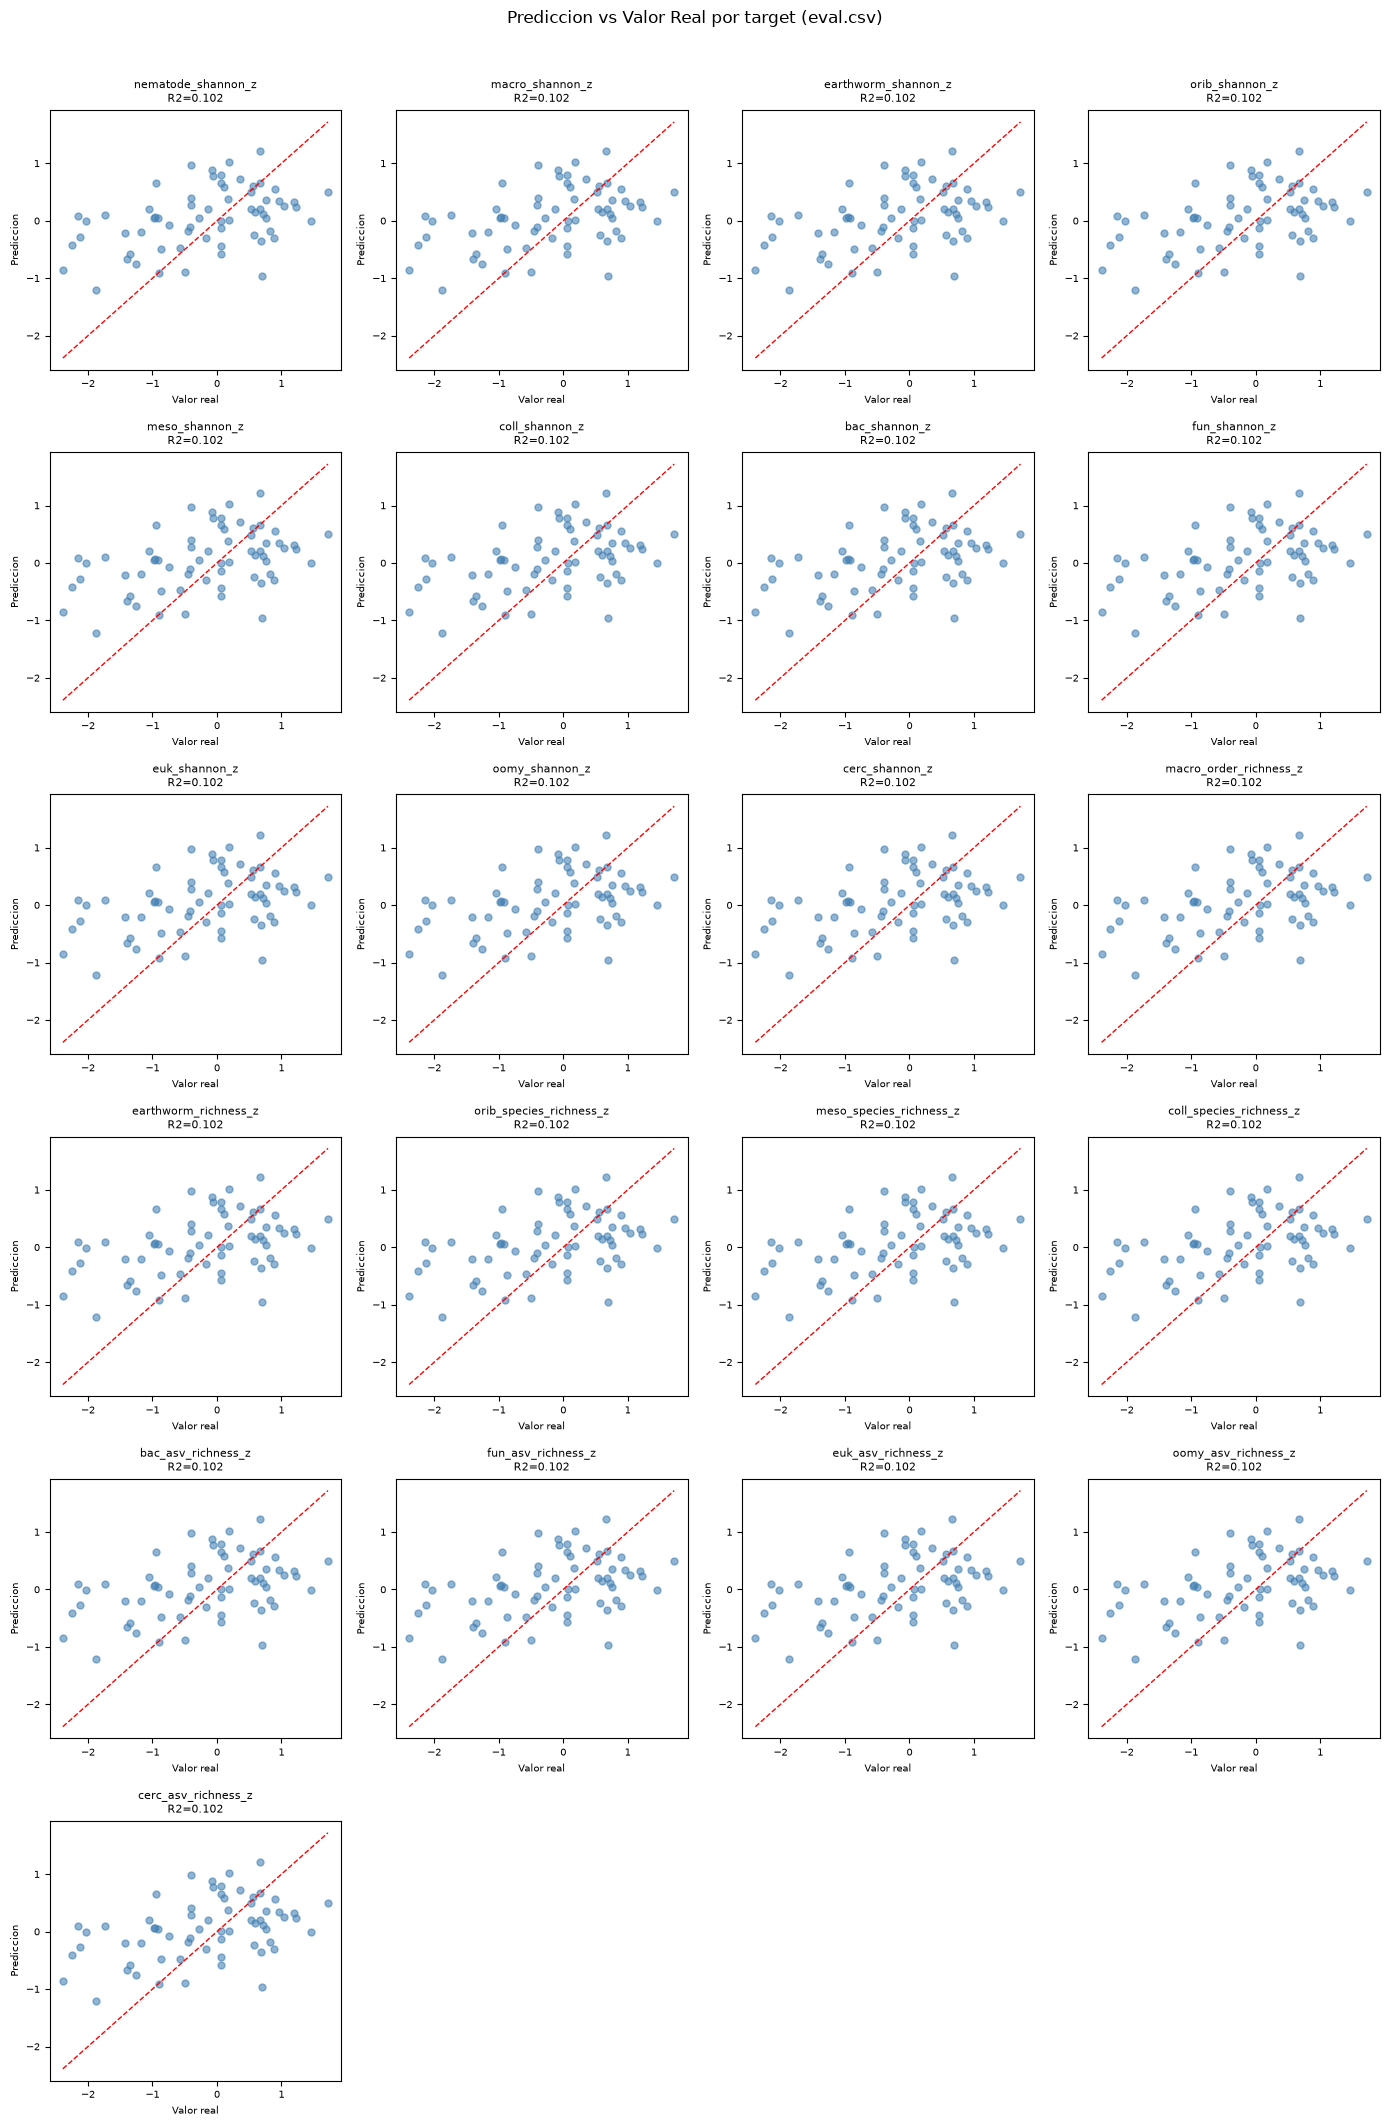

In [13]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

NUM_EXPERTOS = 5


# PARTE A: Evaluacion final sobre todos los targets
# Usamos eval.csv, que el modelo no ha visto hasta ahora.

print('Evaluacion final sobre eval.csv')
print('-' * 65)
print(f'  {"Target":30} {"R2":>8} {"RMSE":>8} {"MAE":>8}')
print('-' * 65)

for test_target in TARGETS:
    # Cargamos los 5 modelos del target actual y promediamos sus predicciones
    preds_eval = []
    for experto_id in range(NUM_EXPERTOS):
        ruta  = os.path.join(MODELS_DIR, f'xgb_prod_{test_target}_exp{experto_id}.pkl')
        model = joblib.load(ruta)
        preds_eval.append(model.predict(X_eval))

    y_pred_eval = np.mean(preds_eval, axis=0)
    y_true_eval = y_eval[test_target].values

    r2   = r2_score(y_true_eval, y_pred_eval)
    rmse = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval))
    mae  = mean_absolute_error(y_true_eval, y_pred_eval)
    print(f'  {test_target:30} {r2:8.4f} {rmse:8.4f} {mae:8.4f}')

print('-' * 65)


# PARTE B: Smoke test con datos reales
# Se prueba sobre dos targets representativos: uno shannon y uno richness.

print('\nSmoke test - Inferencia con datos reales')
print('-' * 65)

try:
    # Tomamos 3 filas reales al azar del dataset de evaluacion
    df_new_data      = X_eval.sample(n=3, random_state=42)
    indices_elegidos = df_new_data.index

    for test_target in ['earthworm_shannon_z', 'earthworm_richness_z']:
        print(f'\n  Target: {test_target}')
        print('  ' + '-' * 63)

        valores_reales = y_eval.loc[indices_elegidos, test_target].values

        # Cada uno de los 5 modelos vota con su propia prediccion para las 3 parcelas
        votos = []
        for experto_id in range(NUM_EXPERTOS):
            ruta  = os.path.join(MODELS_DIR, f'xgb_prod_{test_target}_exp{experto_id}.pkl')
            m     = joblib.load(ruta)
            pred  = m.predict(df_new_data)
            votos.append(pred)
            print(f'  Modelo {experto_id+1} -> '
                  f'Fila {indices_elegidos[0]}: {pred[0]:.4f} | '
                  f'Fila {indices_elegidos[1]}: {pred[1]:.4f} | '
                  f'Fila {indices_elegidos[2]}: {pred[2]:.4f}')

        # Promediamos los 5 votos para obtener la prediccion final de consenso
        consenso = np.mean(votos, axis=0)

        print('  ' + '-' * 63)
        print('  Resultados detallados por muestra evaluada:')
        print('  ' + '-' * 63)

        for i, idx_muestra in enumerate(indices_elegidos):
            pred_val = consenso[i]
            real_val = valores_reales[i]
            error    = abs(pred_val - real_val)
            print(f'    Fila {idx_muestra:<4} | Prediccion: {pred_val:.4f} | '
                  f'Valor Real: {real_val:.4f} | Error absoluto: {error:.4f}')

    print('\nSmoke test superado. El pipeline de XGBoost funciona y predice con coherencia.')

except Exception as e:
    print(f'Error en el smoke test: {str(e)}')

# Grafico: prediccion vs valor real por target
n_targets = len(TARGETS)
n_cols    = 4
n_rows    = (n_targets + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, t in enumerate(TARGETS):
    ax = axes[i]
    ax.scatter(y_true_eval[:, i] if y_true_eval.ndim > 1 else y_true_eval,
               y_pred_eval[:, i] if y_pred_eval.ndim > 1 else y_pred_eval,
               alpha=0.6, s=25, color='steelblue')
    lim = [min((y_true_eval[:, i] if y_true_eval.ndim > 1 else y_true_eval).min(),
               (y_pred_eval[:, i] if y_pred_eval.ndim > 1 else y_pred_eval).min()),
           max((y_true_eval[:, i] if y_true_eval.ndim > 1 else y_true_eval).max(),
               (y_pred_eval[:, i] if y_pred_eval.ndim > 1 else y_pred_eval).max())]
    ax.plot(lim, lim, 'r--', linewidth=1)
    r2_t = r2_score(
        y_true_eval[:, i] if y_true_eval.ndim > 1 else y_true_eval,
        y_pred_eval[:, i] if y_pred_eval.ndim > 1 else y_pred_eval
    )
    ax.set_title(f'{t}\nR2={r2_t:.3f}', fontsize=8)
    ax.set_xlabel('Valor real', fontsize=7)
    ax.set_ylabel('Prediccion', fontsize=7)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Prediccion vs Valor Real por target (eval.csv)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()
